# CPU vs GPU sweep

Goal:

- Run the same sweep, on the same split, on CPU and on GPU.
- Compare hyperparameter sweep time and cost per run.


## Environment

Install libraries.


In [1]:
# psutil backs MLflow's system metrics; pynvml adds the GPU rows on top
%pip install -q -U ultralytics torch torchvision onnx onnxslim onnxruntime mlflow sagemaker-mlflow psutil pynvml

Note: you may need to restart the kernel to use updated packages.

Inspect enironment.


In [2]:
import json
import os
import sys
import time
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import torch

from sagemaker.core.helper.session_helper import Session

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from notebook.code.tracking import tracking_status, tracking_uri

# define paths
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
RUNS = ROOT / "runs"
MODELS = ROOT / "models"

# create dir
for d in (RAW, PROCESSED, RUNS, MODELS):
    d.mkdir(parents=True, exist_ok=True)

REGION = Session().boto_region_name

# get bucket
env_file = Path.home() / ".sagemaker-yolo.env"
if "BUCKET" not in os.environ and env_file.exists():
    for line in env_file.read_text().splitlines():
        key, _, val = line.partition("=")
        os.environ.setdefault(key.strip(), val.strip())

BUCKET = os.environ["BUCKET"]

# bucket keys
S3_RAW = f"s3://{BUCKET}/raw-data/"
S3_SPLIT = f"s3://{BUCKET}/notebook/split-data"
S3_MODELS = f"s3://{BUCKET}/notebook/models"

# get device info: gpu
HAS_GPU = torch.cuda.is_available()

# set tracking server
TRACKING_URI = tracking_uri()
mlflow.set_tracking_uri(TRACKING_URI)

# sample CPU/GPU/memory/disk/network into every run from here on.
# off by default, and silently a no-op if psutil is not installed
mlflow.enable_system_metrics_logging()
# default is one sample every 10s logged individually, which leaves a short run
# with almost no points; sample faster and average to keep the charts readable
mlflow.set_system_metrics_sampling_interval(5)
mlflow.set_system_metrics_samples_before_logging(2)

# set experiment
EXPERIMENT = "yolo-plate-detection-cpu-vs-gpu"
experiment = mlflow.set_experiment(EXPERIMENT)

# get tracking backend UI url (presigned and expiring for the app)
UI_URL = tracking_status(TRACKING_URI)["ui_url"]

# print environment
print("torch     ", torch.__version__)
print("cuda      ", HAS_GPU)
print("gpu       ", torch.cuda.get_device_name(0) if HAS_GPU else "-")
print("cpu count ", os.cpu_count())
print("bucket    ", BUCKET)
print("experiment", EXPERIMENT, f"(id {experiment.experiment_id})")
print(f"\nUI: {UI_URL}/#/experiments/{experiment.experiment_id}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


torch      2.13.0+cu130
cuda       True
gpu        Tesla T4
cpu count  4
bucket     sagemaker-yolo-dev-up68ac
experiment yolo-plate-detection-cpu-vs-gpu (id 3)

UI: https://t-dwc5gdj0ow9o.ca-central-1.experiments.sagemaker.aws/#/experiments/3


Identify the instance. The type is recorded on every run, so the comparison can
say which hardware produced which number.

In [3]:
# Studio writes the space's resource config here
metadata_file = Path("/opt/ml/metadata/resource-metadata.json")
INSTANCE = "unknown"

if metadata_file.exists():
    meta = json.loads(metadata_file.read_text())
    INSTANCE = (
        meta.get("ResourceArn", "").split("/")[-1]
        if "InstanceType" not in meta
        else meta["InstanceType"]
    )
    space = meta.get("SpaceName")
    if space:
        try:
            described = boto3.client("sagemaker").describe_space(
                DomainId=meta["DomainId"], SpaceName=space
            )
            INSTANCE = (
                described["SpaceSettings"]["JupyterLabAppSettings"]
                ["DefaultResourceSpec"]["InstanceType"]
            )
        except Exception as exc:
            print(f"could not read instance type from the space: {exc}")

# passes to run in this session: a GPU box can do both, a CPU box only one
PASSES = [("cpu", "cpu"), ("gpu", 0)] if HAS_GPU else [("cpu", "cpu")]

print("instance  ", INSTANCE)
print("passes    ", [p[0] for p in PASSES])

if not HAS_GPU:
    print(
        "\nNo GPU here, so only the CPU pass runs. To collect the GPU numbers:"
        "\n  1. File > Shut Down all apps (or stop the JupyterLab app in the console)"
        "\n  2. set notebook_instance_type to a GPU type, e.g. ml.g4dn.xlarge"
        "\n  3. terraform apply, restart the app, and run this notebook again"
        "\nThe split is pulled from S3 on the second run, so both passes see"
        "\nexactly the same data."
    )

instance   ml.g4dn.xlarge
passes     ['cpu', 'gpu']


## Data

Train on the identical split.


In [4]:
from notebook.code.data_loader import build_split, verify_split, write_data_yaml
from notebook.code.s3_sync import download, list_objects, upload

# cap the split for a quick check; set to None for the real comparison
# LIMIT = 200
LIMIT = None

SPLIT_SEED = 0

# reuse the split if exists
existing = list_objects(S3_SPLIT)

if existing and LIMIT is None:
    print(f"reusing the split in {S3_SPLIT}/ ({len(existing)} objects)")
    print(download(S3_SPLIT, PROCESSED))
else:
    if existing:
        print(f"LIMIT={LIMIT} set, so rebuilding rather than reusing S3")
    print(download(S3_RAW, RAW))
    print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=SPLIT_SEED))
    print(upload(PROCESSED, S3_SPLIT, delete=True))

print(verify_split(PROCESSED))

names = (RAW / "classes.txt").read_text().split() if (RAW / "classes.txt").exists() else ["car_plate"]
data_yaml = write_data_yaml(ROOT / "configs" / "data.yaml", PROCESSED, names)

n_train = sum(len(list((PROCESSED / s / "images").iterdir())) for s in ("train",))
n_images = sum(len(list((PROCESSED / s / "images").iterdir())) for s in ("train", "val"))
print(f"\n{n_images} images")

reusing the split in s3://sagemaker-yolo-dev-up68ac/notebook/split-data/ (400 objects)


{'downloaded': 0, 'skipped': 400}
{'train': 160, 'val': 40}

200 images


## Define sweep

The same grid runs on both devices.


In [5]:
from itertools import product

from notebook.code.data_loader import build_train_cfg

# the axes to sweep; identical for both devices
SWEEP = {
    "epochs": (10,),
}

GRID = [dict(zip(SWEEP.keys(), values)) for values in product(*SWEEP.values())]

print(f"{len(GRID)} configs x {len(PASSES)} passes = {len(GRID) * len(PASSES)} runs")
for g in GRID:
    print(" ", g)

1 configs x 2 passes = 2 runs
  {'epochs': 10}


## Run sweep

- One MLflow run per config per device. 
- Run names carry the device.

In [6]:
from notebook.code.tracking import run_sweep

results = []

for tag, device in PASSES:
    base_cfg = build_train_cfg(
        device=device,
        # ultralytics forces 0 dataloader workers on CPU
        workers=(os.cpu_count() or 2) if device != "cpu" else 0,
    )
    base_cfg["project"] = str(ROOT / base_cfg["project"])

    grid = [
        {**g, "name": f"{tag}-{n_train}img-{base_cfg['imgsz']}px-"
                      + "-".join(f"{v}{k}" for k, v in g.items())}
        for g in GRID
    ]

    print(f"\n{'#' * 60}\n# {tag} pass on {INSTANCE}\n{'#' * 60}")

    passed = run_sweep(
        grid=grid,
        base_cfg=base_cfg,
        data_yaml=data_yaml,
        processed_dir=PROCESSED,
        raw_dir=RAW,
        experiment=EXPERIMENT,
        run_name=lambda cfg: cfg["name"],
    )

    # tag each run so the comparison can group by device and hardware
    for r in passed:
        r["pass"] = tag
        r["instance"] = INSTANCE
        if "run_id" in r:
            with mlflow.start_run(run_id=r["run_id"]):
                mlflow.set_tags({
                    "pass": tag,
                    "instance": INSTANCE,
                    "cpu_count": os.cpu_count(),
                    "gpu": torch.cuda.get_device_name(0) if device != "cpu" else "none",
                })

    results.extend(passed)

pd.DataFrame(results)


############################################################
# cpu pass on ml.g4dn.xlarge
############################################################



[1/1] cpu-160img-640px-10epochs  {'epochs': 10, 'name': 'cpu-160img-640px-10epochs'}


Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8259CL CPU @ 2.50GHz)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/sagemaker-user/sagemaker-yolo/configs/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cpu-160img-640px-10epochs, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

Overriding model.yaml nc=80 with nc=1


...

MLflow: results logged to arn:aws:sagemaker:ca-central-1:099139718958:mlflow-tracking-server/sagemaker-yolo-dev
MLflow: disable with 'yolo settings mlflow=False'


MLflow: mlflow run still alive, remember to close it using mlflow.end_run()


🏃 View run gpu-160img-640px-10epochs at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/3/runs/7ac2dd45018e45268d337203cd836e2f
🧪 View experiment at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/3
[1/1] done in 63s


🏃 View run gpu-160img-640px-10epochs at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/3/runs/7ac2dd45018e45268d337203cd836e2f
🧪 View experiment at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/3


,name,run_id,save_dir,epochs,mAP50,mAP50-95,elapsed_s,pass,instance
0,cpu-160img-640px-10epochs,660dae4ed7914fb99ba41225d5c36293,/home/sagemaker-user/sagemaker-yolo/runs/cpu-1...,10,0.779561,0.611877,627,cpu,ml.g4dn.xlarge
1,gpu-160img-640px-10epochs,7ac2dd45018e45268d337203cd836e2f,/home/sagemaker-user/sagemaker-yolo/runs/gpu-1...,10,0.680899,0.547945,63,gpu,ml.g4dn.xlarge


## Compare

Read both passes back from MLflow.


In [7]:
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

if runs.empty:
    raise RuntimeError("no runs in the experiment yet")

# elapsed_seconds is logged by run_sweep; tags.pass by the cell above
table = pd.DataFrame({
    "run": runs["tags.mlflow.runName"],
    "pass": runs.get("tags.pass"),
    "instance": runs.get("tags.instance"),
    "start": runs["start_time"],
    "epochs": pd.to_numeric(runs.get("params.epochs"), errors="coerce"),
    "images": pd.to_numeric(runs.get("params.data.total_images"), errors="coerce"),
    "seconds": pd.to_numeric(runs.get("metrics.elapsed_seconds"), errors="coerce"),
    "mAP50-95": pd.to_numeric(runs.get("metrics.metrics/mAP50-95B"), errors="coerce"),
}).dropna(subset=["seconds", "pass"])

before = len(table)
table = table.sort_values("start", ascending=False).drop_duplicates(
    subset=["pass", "epochs", "images"], keep="first"
)
if before != len(table):
    print(f"dropped {before - len(table)} superseded run(s) from earlier sessions")

have = set(table["pass"].unique())
print("passes on the server:", sorted(have))

for label, subset in table.groupby("pass"):
    print(f"  {label:4} {len(subset)} runs on {sorted(set(subset['instance'].dropna()))}")

if {"cpu", "gpu"} - have:
    print(
        f"\nMissing the {sorted({'cpu', 'gpu'} - have)[0]} pass — "
        "the comparison below stays empty until both exist."
    )

table.sort_values(["epochs", "pass"])

dropped 11 superseded run(s) from earlier sessions
passes on the server: ['cpu', 'gpu']
  cpu  2 runs on ['ml.g4dn.xlarge']
  gpu  2 runs on ['ml.g4dn.xlarge']


,run,pass,instance,start,epochs,images,seconds,mAP50-95
1,cpu-160img-640px-10epochs,cpu,ml.g4dn.xlarge,2026-08-14 00:34:37.735000+00:00,10,200,627.384995,0.611877
0,gpu-160img-640px-10epochs,gpu,ml.g4dn.xlarge,2026-08-14 00:45:07.591000+00:00,10,200,62.886413,0.547945
6,cpu-160img-640px-20epochs,cpu,ml.g4dn.xlarge,2026-08-13 23:45:42.462000+00:00,20,200,1234.741550,0.759494
4,gpu-160img-640px-20epochs,gpu,ml.g4dn.xlarge,2026-08-14 00:07:24.795000+00:00,20,200,89.885746,0.798119


### Speedup

Matched on `epochs` and image count, so each row compares like with like.

In [8]:
BOTH = not ({"cpu", "gpu"} - have)

if not BOTH:
    print("need both passes before this can be computed")
else:
    cpu = table[table["pass"] == "cpu"].set_index(["epochs", "images"])
    gpu = table[table["pass"] == "gpu"].set_index(["epochs", "images"])

    speedup = pd.DataFrame({
        "cpu_min": (cpu["seconds"] / 60).round(1),
        "gpu_min": (gpu["seconds"] / 60).round(1),
        "cpu_mAP": cpu["mAP50-95"].round(4),
        "gpu_mAP": gpu["mAP50-95"].round(4),
    }).dropna()

    speedup["speedup"] = (speedup["cpu_min"] / speedup["gpu_min"]).round(1)
    speedup["mAP_delta"] = (speedup["gpu_mAP"] - speedup["cpu_mAP"]).round(4)

    display(speedup.reset_index())

    print(f"\nmedian speedup {speedup['speedup'].median():.1f}x")
    # different kernels and reduction orders, so exact parity is not expected
    print(f"largest mAP gap {speedup['mAP_delta'].abs().max():.4f}"
          " (small values confirm the two devices agree)")

,epochs,images,cpu_min,gpu_min,cpu_mAP,gpu_mAP,speedup,mAP_delta
0,10,200,10.5,1.0,0.6119,0.5479,10.5,-0.0640
1,20,200,20.6,1.5,0.7595,0.7981,13.7,0.0386



median speedup 12.1x
largest mAP gap 0.0640 (small values confirm the two devices agree)


Wall-clock per config.

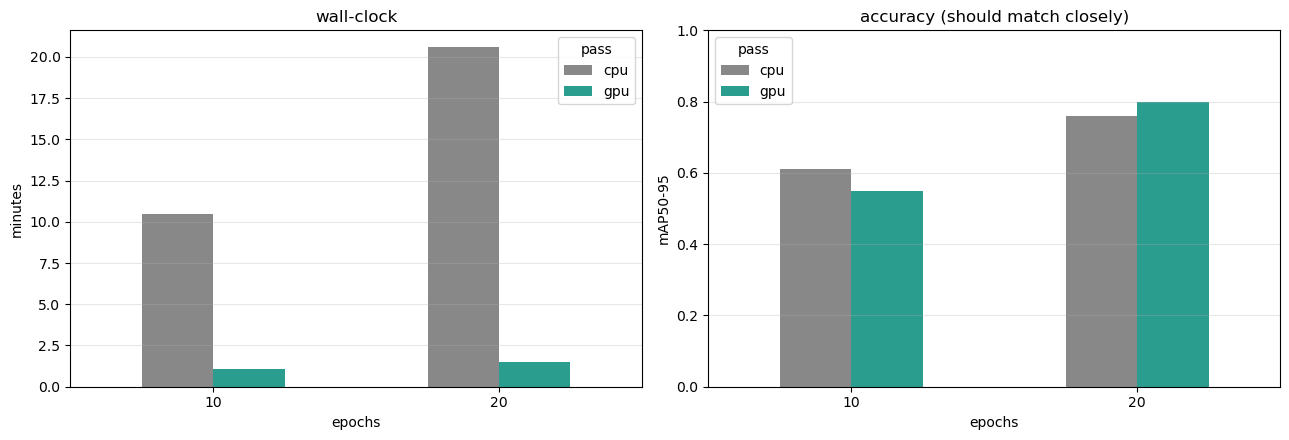

In [9]:
%matplotlib inline

if not BOTH:
    print("need both passes before this can be plotted")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    pivot = table.pivot_table(index="epochs", columns="pass", values="seconds") / 60
    pivot.plot(kind="bar", ax=axes[0], color={"cpu": "#888", "gpu": "#2a9d8f"})
    axes[0].set_ylabel("minutes")
    axes[0].set_xlabel("epochs")
    axes[0].set_title("wall-clock")
    axes[0].grid(alpha=0.3, axis="y")
    axes[0].tick_params(axis="x", rotation=0)

    acc = table.pivot_table(index="epochs", columns="pass", values="mAP50-95")
    acc.plot(kind="bar", ax=axes[1], color={"cpu": "#888", "gpu": "#2a9d8f"})
    axes[1].set_ylabel("mAP50-95")
    axes[1].set_xlabel("epochs")
    axes[1].set_title("accuracy (should match closely)")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3, axis="y")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()


### Cost


In [10]:
# USD per hour, on-demand. Update for your region before relying on this.
RATES = {
    "ml.t3.xlarge": 0.223,
    "ml.g4dn.xlarge": 0.818,
}

if not BOTH:
    print("need both passes before this can be computed")
else:
    cost = table.copy()
    cost["rate"] = cost["instance"].map(RATES)
    unpriced = sorted(set(cost.loc[cost["rate"].isna(), "instance"].dropna()))

    if unpriced:
        print(f"no rate for {unpriced} — add them to RATES")

    cost["usd"] = (cost["seconds"] / 3600 * cost["rate"]).round(3)
    summary = cost.groupby("pass").agg(
        instance=("instance", "first"),
        rate_per_hour=("rate", "first"),
        total_min=("seconds", lambda s: round(s.sum() / 60, 1)),
        total_usd=("usd", "sum"),
    ).round(3)

    display(summary)

    if summary["total_usd"].notna().all() and len(summary) == 2:
        cheaper = summary["total_usd"].idxmin()
        ratio = summary["total_usd"].max() / summary["total_usd"].min()
        print(f"\n{cheaper} is {ratio:.1f}x cheaper for this sweep")

,instance,rate_per_hour,total_min,total_usd
pass,,,,
cpu,ml.g4dn.xlarge,0.818,31.0,0.424
gpu,ml.g4dn.xlarge,0.818,2.5,0.034



gpu is 12.5x cheaper for this sweep
